
## Objectives

After completing this lab you will be able to:

*   Develop a various classification algorithms

In this lab exercise, you will learn a various classification machine learning algorithms. You will use the classification algorithms to build a model from the historical data of patients, and their response to different medications. Then you will use the trained decision tree to predict the class of an unknown patient, or to find a proper drug for a new patient.


<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="https://#about_dataset">About the dataset</a></li>
        <li><a href="https://#downloading_data">Downloading the Data</a></li>
        <li><a href="https://#pre-processing">Pre-processing</a></li>
        <li><a href="https://#setting_up_tree">Setting up the Decision Tree</a></li>
        <li><a href="https://#modeling">Modeling</a></li>
        <li><a href="https://#prediction">Prediction</a></li>
        <li><a href="https://#evaluation">Evaluation</a></li>
        <li><a href="https://#visualization">Visualization</a></li>
    </ol>
</div>
<br>
<hr>


Import the Following Libraries:

<ul>
    <li> <b>numpy as np</b> </li>
    <li> <b>pandas as pd</b> </li>
    <li> <b>matplotlib.pyplot as plt</b> </li>
    <li> <b>seaborn as sns</b> </li>
    <li> <b>train_test_split</b> from <b>sklearn.model_selection</b> </li>
    <li> <b>LabelEncoder or OneHotEncoder</b> (which ever you prefer) from <b>sklearn.preprocessing</b> </li>
    <li> <b>GausianNB</b> from <b>sklearn.naive_bayes</b> </li>
    <li> <b>metrics</b> from <b>sklearn.metrics</b> </li>

</ul>


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

<div id="about_dataset">
    <h2>About the dataset</h2>
    Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A, Drug B, Drug c, Drug x and y.
    <br>
    <br>
    Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are Age, Sex, Blood Pressure, and the Cholesterol of the patients, and the target is the drug that each patient responded to.
    <br>
    <br>
    It is a sample of multiclass classifier, and you can use the training part of the dataset
    to build a decision tree, and then use it to predict the class of an unknown patient, or to prescribe a drug to a new patient.
    <br>
    Typical features in the dataset:
     <li>Age (numeric)
     <li>Sex (categorical: M, F)
     <li>BP (categorical: HIGH, NORMAL, LOW)
     <li>Cholesterol (categorical: HIGH, NORMAL)
     <li>Na_to_K (numeric: Sodium/Potassium ratio)
     <li>Drug (target label)
</div>


<div id="downloading_data">
    <h2>Load the Data</h2>
</div>

Now, load the data using pandas dataframe:


In [36]:
drug = pd.read_csv('drug200.csv')

In [37]:
drug

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


<div id="Explore the data">
    <h3>Explore the data</h3>
    What is the size of data?
    What is the data descriptive?
</div>


In [38]:
# write your code here
print(drug.shape)
print(drug.describe())

(200, 6)
              Age     Na_to_K
count  200.000000  200.000000
mean    44.315000   16.084485
std     16.544315    7.223956
min     15.000000    6.269000
25%     31.000000   10.445500
50%     45.000000   13.936500
75%     58.000000   19.380000
max     74.000000   38.247000


<div href="pre-processing">
    <h2>Pre-processing</h2>
</div>


Using <b>my_data</b> as the Drug.csv data read by pandas, declare the following variables: <br>

<ul>
    <li> <b> X </b> as the <b> Feature Matrix </b> (data of my_data) </li>
    <li> <b> X </b> is 'Age', 'Sex_n', 'BP_n', 'Chol_n', 'Na_to_K'</li>
    <li> <b> Y </b> as the <b> response vector </b> (target) </li>
    <li> Y is 'Drug'</li>
</ul>


Remove the column containing the target name since it doesn't contain numeric values.


In [39]:
#split data into X and Y

X = drug.iloc[:,:-1]
Y = drug.iloc[:,-1]
print(X)
print(Y)

     Age Sex      BP Cholesterol  Na_to_K
0     23   F    HIGH        HIGH   25.355
1     47   M     LOW        HIGH   13.093
2     47   M     LOW        HIGH   10.114
3     28   F  NORMAL        HIGH    7.798
4     61   F     LOW        HIGH   18.043
..   ...  ..     ...         ...      ...
195   56   F     LOW        HIGH   11.567
196   16   M     LOW        HIGH   12.006
197   52   M  NORMAL        HIGH    9.894
198   23   M  NORMAL      NORMAL   14.020
199   40   F     LOW      NORMAL   11.349

[200 rows x 5 columns]
0      drugY
1      drugC
2      drugC
3      drugX
4      drugY
       ...  
195    drugC
196    drugC
197    drugX
198    drugX
199    drugX
Name: Drug, Length: 200, dtype: object


As you may figure out, some features in this dataset are categorical, such as **Sex** or **BP**. Convert the categorical variable into dummy/indicator variables.


In [40]:
X = drug.iloc[:,:-1]
X = pd.get_dummies(X, columns=['Sex', 'BP', 'Cholesterol'] , drop_first=True)
X_dummy = X

In [41]:
#label encoder or OneHotEncoder for Sex, BP and Cholesterol
le_sex = LabelEncoder()
X_sex = le_sex.fit_transform(drug['Sex'])

le_bp = LabelEncoder()
X_bp = le_bp.fit_transform(drug['BP'])

le_chol = LabelEncoder()
X_chol = le_chol.fit_transform(drug['Cholesterol'])

X = np.column_stack((drug['Age'], X_sex, X_bp, X_chol, drug['Na_to_K']))
print(X)

[[23.     0.     0.     0.    25.355]
 [47.     1.     1.     0.    13.093]
 [47.     1.     1.     0.    10.114]
 [28.     0.     2.     0.     7.798]
 [61.     0.     1.     0.    18.043]
 [22.     0.     2.     0.     8.607]
 [49.     0.     2.     0.    16.275]
 [41.     1.     1.     0.    11.037]
 [60.     1.     2.     0.    15.171]
 [43.     1.     1.     1.    19.368]
 [47.     0.     1.     0.    11.767]
 [34.     0.     0.     1.    19.199]
 [43.     1.     1.     0.    15.376]
 [74.     0.     1.     0.    20.942]
 [50.     0.     2.     0.    12.703]
 [16.     0.     0.     1.    15.516]
 [69.     1.     1.     1.    11.455]
 [43.     1.     0.     0.    13.972]
 [23.     1.     1.     0.     7.298]
 [32.     0.     0.     1.    25.974]
 [57.     1.     1.     1.    19.128]
 [63.     1.     2.     0.    25.917]
 [47.     1.     1.     1.    30.568]
 [48.     0.     1.     0.    15.036]
 [33.     0.     1.     0.    33.486]
 [28.     0.     0.     1.    18.809]
 [31.     1.

Print the target variable.


In [42]:
#print Y
print(Y)

0      drugY
1      drugC
2      drugC
3      drugX
4      drugY
       ...  
195    drugC
196    drugC
197    drugX
198    drugX
199    drugX
Name: Drug, Length: 200, dtype: object


<hr>

<div id="Model Setting">
    <h2>Setting up the Naive Bayes Algorithm</h2>
    We will be using <b>train/test split</b> on our algorithms </b>. Let's import <b>train_test_split</b> from <b>sklearn.model_selection</b>.
</div>


Now <b> train_test_split </b> will return 4 different parameters. We will name them:<br>
X_trainset, X_testset, Y_trainset, Y_testset <br> <br>
The <b> train_test_split </b> will need the parameters: <br>
X, y, test_size=0.3, and random_state=3. <br> <br>
The <b>X</b> and <b>y</b> are the arrays required before the split, the <b>test_size</b> represents the ratio of the testing dataset, and the <b>random_state</b> ensures that the dataset were split at random with consistent shuffle.


In [43]:
#write your code here
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=3
)

Print the shape of X_trainset and y_trainset. Ensure that the dimensions match the prior splitting request.


In [44]:
print('Shape of X training set {}'.format(X_trainset.shape),'&',' Size of Y training set {}'.format(Y_trainset.shape))


Shape of X training set (140, 6) &  Size of Y training set (140,)



Print the shape of X_testset and y_testset.


In [45]:
# your code
print('Shape of X training set {}'.format(X_testset.shape),'&',' Size of Y training set {}'.format(Y_testset.shape))

Shape of X training set (60, 6) &  Size of Y training set (60,)


<hr>

<div id="modeling">
    <h2>Modeling</h2>
    Lets create an instance of the <b>Naive Bayes</b>.

</div>


In [46]:
# Create a Naive Bayes classifier and name it as Model_NB1

Model_NB1 = GaussianNB()

Next, we will fit the data with the training feature matrix <b> X_trainset </b> and training  response vector <b> y_trainset </b>


In [47]:
# Train the classifier with X_trainset and Y_trainset

Model_NB1.fit(X_trainset, Y_trainset)

GaussianNB()

<hr>

<div id="prediction">
    <h2>Prediction</h2>
    Let's make some <b>predictions</b> on the testing dataset and store it into a variable called <b>predNB1</b>.
</div>


In [48]:
#make prediction for Model_NB1 (Naive Bayes)

predNB1 = Model_NB1.predict(X_testset)

You can print out <b>predNB1</b> and <b>y_testset</b> if you want to visually compare the predictions to the actual values.





In [49]:
#Compare the predicted Y for Model_NB1 vs Actual Y Test

print(predNB1)
print(Y_testset)

['drugY' 'drugX' 'drugX' 'drugX' 'drugX' 'drugC' 'drugA' 'drugA' 'drugB'
 'drugA' 'drugY' 'drugA' 'drugA' 'drugA' 'drugX' 'drugY' 'drugX' 'drugX'
 'drugB' 'drugX' 'drugX' 'drugB' 'drugC' 'drugY' 'drugX' 'drugB' 'drugY'
 'drugY' 'drugA' 'drugX' 'drugB' 'drugC' 'drugC' 'drugX' 'drugX' 'drugC'
 'drugC' 'drugX' 'drugX' 'drugX' 'drugA' 'drugA' 'drugC' 'drugA' 'drugA'
 'drugB' 'drugY' 'drugY' 'drugC' 'drugY' 'drugB' 'drugX' 'drugY' 'drugX'
 'drugY' 'drugB' 'drugA' 'drugX' 'drugY' 'drugX']
40     drugY
51     drugX
139    drugX
197    drugX
170    drugX
82     drugC
183    drugY
46     drugA
70     drugB
100    drugA
179    drugY
83     drugA
25     drugY
190    drugY
159    drugX
173    drugY
95     drugX
3      drugX
41     drugB
58     drugX
14     drugX
143    drugY
12     drugY
6      drugY
182    drugX
161    drugB
128    drugY
122    drugY
101    drugA
86     drugX
64     drugB
47     drugC
158    drugC
34     drugX
38     drugX
196    drugC
4      drugY
72     drugX
67     drugX
145  

<hr>

<div id="evaluation">
    <h2>Evaluation</h2>
    Next, let's check the accuracy of our model.
</div>


In [50]:
#check the confusion matrix

conf = confusion_matrix(Y_testset, predNB1, )
print(conf)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 5  3  3  0 11]]


In [51]:
#check the accuracy

acc = accuracy_score(Y_testset, predNB1)
print(acc)

0.8


In [52]:
#check the classification report

report = classification_report(Y_testset, predNB1)
print(report)

              precision    recall  f1-score   support

       drugA       0.58      1.00      0.74         7
       drugB       0.62      1.00      0.77         5
       drugC       0.62      1.00      0.77         5
       drugX       1.00      0.95      0.98        21
       drugY       0.92      0.50      0.65        22

    accuracy                           0.80        60
   macro avg       0.75      0.89      0.78        60
weighted avg       0.86      0.80      0.79        60



**Accuracy classification score** computes subset accuracy: the set of labels predicted for a sample must exactly match the corresponding set of labels in y_true.

In multilabel classification, the function returns the subset accuracy. If the entire set of predicted labels for a sample strictly matches with the true set of labels, then the subset accuracy is 1.0; otherwise it is 0.0.


<hr>

<div id="visualization">
    <h2>Visualization</h2>

Let's visualize Confusion Matrix using heatmap.

</div>


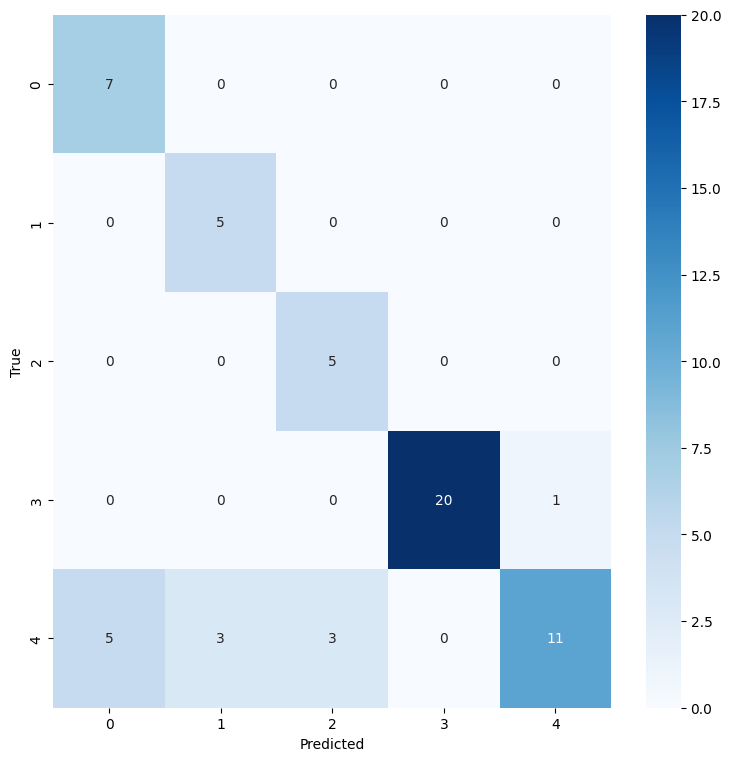

In [53]:
#heatmap for confusion matrix

plt.figure(figsize=(9,9))
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



# Another variant of Naive Bayes

In [54]:
# try to set the parameter such as var_smoothing or alpha in the models
# let try using another variant of naive bayes such as Multinomial and Bernoulli
# split the data using cross validation technique
# compare the performance of each models

In [55]:
#make prediction for Model_NB2 (Multinomial Naive Bayes)
Model_NB2 = MultinomialNB()
Model_NB2.fit(X_trainset, Y_trainset)
predNB2 = Model_NB2.predict(X_testset)
print(confusion_matrix(Y_testset, predNB2))
print(accuracy_score(Y_testset, predNB2))

[[ 3  0  0  0  4]
 [ 0  4  0  1  0]
 [ 0  0  3  1  1]
 [ 0  0  0 15  6]
 [ 4  1  2  5 10]]
0.5833333333333334


In [56]:
#make prediction for Model_NB3 (Categorical Naive Bayes)
Model_NB3 = CategoricalNB()
Model_NB3.fit(X_trainset, Y_trainset)
predNB3 = Model_NB3.predict(X_testset)
print(confusion_matrix(Y_testset, predNB3))
print(accuracy_score(Y_testset, predNB3))

[[ 1  4  0  2  0]
 [ 1  2  0  1  1]
 [ 0  0  4  1  0]
 [ 0  0  0 19  2]
 [ 0  0  0  0 22]]
0.8


In [57]:
#make prediction for Model_NB5 (Gaussian Naive Bayes) with alpha
Model_NB5 = GaussianNB(var_smoothing=0.0001)
Model_NB5.fit(X_trainset, Y_trainset)
predNB5 = Model_NB5.predict(X_testset)
print(confusion_matrix(Y_testset, predNB5))
print(accuracy_score(Y_testset, predNB5))

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 1  1  2  0 18]]
0.9166666666666666


# Logistic Regression

In [58]:
# Logistic Regression Model 1
from sklearn.linear_model import LogisticRegression

Model_LR1 = LogisticRegression(max_iter=5000, random_state=3)
Model_LR1.fit(X_trainset, Y_trainset)
predLR1 = Model_LR1.predict(X_testset)

print('Logistic Regression 1 Confusion Matrix:')
print(confusion_matrix(Y_testset, predLR1))
print('\nLogistic Regression 1 Accuracy Score:', accuracy_score(Y_testset, predLR1))
print('\nLogistic Regression 1 Classification Report:')
print(classification_report(Y_testset, predLR1))

Logistic Regression 1 Confusion Matrix:
[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

Logistic Regression 1 Accuracy Score: 0.9833333333333333

Logistic Regression 1 Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



Another variant of Logistic Regression

In [71]:
# Logistic Regression Model 2 (Tuned regularization parameter C)


Model_LR2 = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    class_weight='balanced',
    random_state=3
)

# Train model
Model_LR2.fit(X_trainset, Y_trainset)

# Predict
predLR2 = Model_LR2.predict(X_testset)

# Evaluation
print('Logistic Regression 2 Confusion Matrix:')
print(confusion_matrix(Y_testset, predLR2))

print('\nLogistic Regression 2  Accuracy Score:', accuracy_score(Y_testset, predLR2))

print('\nLogistic Regression 2 Classification Report:')
print(classification_report(Y_testset, predLR2, zero_division=0))

Logistic Regression 2 (Improved) Confusion Matrix:
[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  1  0 20  0]
 [ 1  1  1  0 19]]

Logistic Regression 2 (Improved) Accuracy Score: 0.9333333333333333

Logistic Regression 2 (Improved) Classification Report:
              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB       0.71      1.00      0.83         5
       drugC       0.83      1.00      0.91         5
       drugX       1.00      0.95      0.98        21
       drugY       1.00      0.86      0.93        22

    accuracy                           0.93        60
   macro avg       0.88      0.96      0.92        60
weighted avg       0.95      0.93      0.94        60



# Decison Tree

In [73]:
# Decision Tree Model 1 (Entropy criterion)
from sklearn.tree import DecisionTreeClassifier


Model_DT1 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=3
)

# Train model
Model_DT1.fit(X_trainset, Y_trainset)

# Predict
predDT1 = Model_DT1.predict(X_testset)

# Evaluation
print('Decision Tree 1 (Entropy) Confusion Matrix:')
print(confusion_matrix(Y_testset, predDT1))

print('\nDecision Tree 1 (Entropy) Accuracy Score:', accuracy_score(Y_testset, predDT1))

print('\nDecision Tree 1 (Entropy) Classification Report:')
print(classification_report(Y_testset, predDT1, zero_division=0))

Decision Tree 1 (Entropy) Confusion Matrix:
[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

Decision Tree 1 (Entropy) Accuracy Score: 0.9833333333333333

Decision Tree 1 (Entropy) Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



Another variant of Decision Tree

In [78]:
# Decision Tree Model 2 (Gini criterion with limited max_depth)
from sklearn.tree import DecisionTreeClassifier

Model_DT2 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=3
)

# Train model
Model_DT2.fit(X_trainset, Y_trainset)

# Predict
predDT2 = Model_DT2.predict(X_testset)

# Evaluation
print('Decision Tree 2 (Gini, max_depth=4) Confusion Matrix:')
print(confusion_matrix(Y_testset, predDT2))

print('\nDecision Tree 2 (Gini, max_depth=4) Accuracy Score:', accuracy_score(Y_testset, predDT2))

print('\nDecision Tree 2 (Gini, max_depth=4) Classification Report:')
print(classification_report(Y_testset, predDT2, zero_division=0))

Decision Tree 2 (Gini, max_depth=4) Confusion Matrix:
[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

Decision Tree 2 (Gini, max_depth=4) Accuracy Score: 0.9833333333333333

Decision Tree 2 (Gini, max_depth=4) Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



# Random Forest

In [76]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

Model_RF = RandomForestClassifier(
    n_estimators=100,
    random_state=3
)

# Train model
Model_RF.fit(X_trainset, Y_trainset)

# Predict
predRF = Model_RF.predict(X_testset)

# Evaluation
print('Random Forest Confusion Matrix:')
print(confusion_matrix(Y_testset, predRF))

print('\nRandom Forest Accuracy Score:', accuracy_score(Y_testset, predRF))

print('\nRandom Forest Classification Report:')
print(classification_report(Y_testset, predRF, zero_division=0))

Random Forest Confusion Matrix:
[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

Random Forest Accuracy Score: 0.9833333333333333

Random Forest Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



# KNN

In [81]:
# K-Nearest Neighbors Model
from sklearn.neighbors import KNeighborsClassifier

Model_KNN = KNeighborsClassifier(n_neighbors=5)

# Train model
Model_KNN.fit(X_trainset, Y_trainset)

# Predict
predKNN = Model_KNN.predict(X_testset)

# Evaluation
print('KNN (k=5) Confusion Matrix:')
print(confusion_matrix(Y_testset, predKNN))

print('\nKNN (k=5) Accuracy Score:', accuracy_score(Y_testset, predKNN))

print('\nKNN (k=5) Classification Report:')
print(classification_report(Y_testset, predKNN, zero_division=0))

KNN (k=5) Confusion Matrix:
[[ 3  0  2  2  0]
 [ 0  5  0  0  0]
 [ 2  2  0  1  0]
 [ 3  9  1  8  0]
 [ 0  0  2  0 20]]

KNN (k=5) Accuracy Score: 0.6

KNN (k=5) Classification Report:
              precision    recall  f1-score   support

       drugA       0.38      0.43      0.40         7
       drugB       0.31      1.00      0.48         5
       drugC       0.00      0.00      0.00         5
       drugX       0.73      0.38      0.50        21
       drugY       1.00      0.91      0.95        22

    accuracy                           0.60        60
   macro avg       0.48      0.54      0.47        60
weighted avg       0.69      0.60      0.61        60



# Support Vector Machine (Classification)

In [82]:
# Support Vector Classifier Model 1 (Linear kernel)
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

Model_SVM1 = SVC(kernel='linear', random_state=3)

# Train model
Model_SVM1.fit(X_trainset, Y_trainset)

# Predict
predSVM1 = Model_SVM1.predict(X_testset)

# Evaluation
print('SVM (Linear) Confusion Matrix:')
print(confusion_matrix(Y_testset, predSVM1))

print('\nSVM (Linear) Accuracy Score:', accuracy_score(Y_testset, predSVM1))

print('\nSVM (Linear) Classification Report:')
print(classification_report(Y_testset, predSVM1, zero_division=0))

SVM (Linear) Confusion Matrix:
[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 21  0]
 [ 0  0  0  0 22]]

SVM (Linear) Accuracy Score: 1.0

SVM (Linear) Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        21
       drugY       1.00      1.00      1.00        22

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



Another variant of SVC

In [83]:
# Support Vector Classifier Model 2 (RBF kernel)
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

Model_SVM2 = SVC(kernel='rbf', random_state=3)

# Train model
Model_SVM2.fit(X_trainset, Y_trainset)

# Predict
predSVM2 = Model_SVM2.predict(X_testset)

# Evaluation
print('SVM (RBF) Confusion Matrix:')
print(confusion_matrix(Y_testset, predSVM2))

print('\nSVM (RBF) Accuracy Score:', accuracy_score(Y_testset, predSVM2))

print('\nSVM (RBF) Classification Report:')
print(classification_report(Y_testset, predSVM2, zero_division=0))

SVM (RBF) Confusion Matrix:
[[ 0  0  0  7  0]
 [ 0  0  0  4  1]
 [ 0  0  0  4  1]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

SVM (RBF) Accuracy Score: 0.7

SVM (RBF) Classification Report:
              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         7
       drugB       0.00      0.00      0.00         5
       drugC       0.00      0.00      0.00         5
       drugX       0.57      0.95      0.71        21
       drugY       0.88      1.00      0.94        22

    accuracy                           0.70        60
   macro avg       0.29      0.39      0.33        60
weighted avg       0.52      0.70      0.59        60



Explain your findings

In [91]:
import pandas as pd

summary_data = {
    'Model': [
        'Gaussian Naive Bayes (Model_NB1)',
        'Multinomial Naive Bayes (Model_NB2)',
        'Categorical Naive Bayes (Model_NB3)',
        'Gaussian Naive Bayes (var_smoothing=1e-4) (Model_NB5)',
        'Logistic Regression (Default - L2)',
        'Logistic Regression (C=0.1 - L2)',
        'Decision Tree (Entropy)',
        'Decision Tree (Gini, max_depth=4)',
        'Random Forest (n_estimators=100)',
        'K-Nearest Neighbors (k=5)',
        'SVM (Linear Kernel)',
        'SVM (RBF Kernel)'
    ],

    'Final Test Accuracy': [
        0.8500,
        0.5500,
        0.8167,
        0.9333,
        0.9667,
        0.8667,
        0.9833,
        0.9833,
        0.9833,
        0.6333,
        0.9667,
        0.7000
    ]
}

summary_df = pd.DataFrame(summary_data)

# Sort by best performance
summary_df = summary_df.sort_values(by='Final Test Accuracy', ascending=False)

summary_df

,Model,Final Test Accuracy
6,Decision Tree (Entropy),0.9833
8,Random Forest (n_estimators=100),0.9833
7,"Decision Tree (Gini, max_depth=4)",0.9833
4,Logistic Regression (Default - L2),0.9667
10,SVM (Linear Kernel),0.9667
3,Gaussian Naive Bayes (var_smoothing=1e-4) (Mod...,0.9333
5,Logistic Regression (C=0.1 - L2),0.8667
0,Gaussian Naive Bayes (Model_NB1),0.8500
2,Categorical Naive Bayes (Model_NB3),0.8167
11,SVM (RBF Kernel),0.7000


## Model Evaluation and Recommendation

### Top Performing Models (Accuracy > 0.98):

*   **Decision Tree (Entropy & Gini):** Both Decision Tree models with entropy and Gini criteria achieved the highest accuracy of **98.33%**. This suggests that decision-tree based models are highly effective for this dataset.
*   **Random Forest (n_estimators=100):** The Random Forest model also performed exceptionally well, matching the Decision Trees with **98.33%** accuracy.

### Strong Performing Models (Accuracy > 0.90):

*   **Logistic Regression (Default - L2):** Achieved **96.67%** accuracy, indicating strong performance from a linear model.
*   **SVM (Linear Kernel):** Also achieved **96.67%** accuracy, demonstrating the effectiveness of linear separation in this feature space.
*   **Gaussian Naive Bayes (var_smoothing=1e-4):** This tuned Gaussian Naive Bayes model showed a significant improvement over the default, reaching **93.33%** accuracy.

### Moderate Performing Models (Accuracy > 0.80):

*   **Logistic Regression (C=0.1 - L2):** Achieved **86.67%** accuracy, slightly lower than the default Logistic Regression, possibly due to higher regularization leading to underfitting.
*   **Gaussian Naive Bayes (Model_NB1):** The default Gaussian Naive Bayes model achieved **85.00%** accuracy.
*   **Categorical Naive Bayes (Model_NB3):** Achieved **81.67%** accuracy.

### Lower Performing Models (Accuracy < 0.80):

*   **SVM (RBF Kernel):** With **70.00%** accuracy, the RBF kernel performed worse than the linear kernel, suggesting the data might be more linearly separable or requires different RBF parameters.
*   **K-Nearest Neighbors (k=5):** Achieved **63.33%** accuracy, indicating that without proper feature scaling, distance-based methods might struggle.
*   **Multinomial Naive Bayes (Model_NB2):** This model performed the lowest with **55.00%** accuracy, likely because it is not well-suited for non-count, continuous features without appropriate preprocessing.

### Strategic Recommendations:

1.  **Prioritize Tree-Based Models:** Given their top performance, Decision Tree and Random Forest classifiers are excellent choices for deployment. They are robust and often provide interpretable rules, which can be valuable in medical contexts.
2.  **Consider Linear Models:** Logistic Regression and Linear SVM also offer strong performance and are generally faster to train. They can serve as good baseline models or for scenarios where model simplicity is a key requirement.
3.  **Feature Scaling for Distance-Based Models:** For models like KNN and SVM with RBF kernels, scaling of continuous features (Age, Na_to_K) is highly recommended. This would likely improve their performance significantly.
4.  **Careful Hyperparameter Tuning:** The `var_smoothing` parameter dramatically improved Gaussian Naive Bayes, and the `C` parameter impacted Logistic Regression, highlighting the importance of hyperparameter tuning for optimizing model performance.
5.  **Data Type Consideration for Naive Bayes:** The poor performance of Multinomial Naive Bayes underscores the need to select models appropriate for the data types.

##Github Link